# Real network from Therion survey (P. Vernant data)

This notebook uses a real data set and demonstrates how karstnet can be used to:
- load the geometry of karstic network from two ASCII files or a Therion SQL file;
- plot the geometry and its simplification;
- computes the statistical properties of the network.
- plot density map of orientations and rose diagram

Nov. 2019 -updated Aug. 2020

In [1]:
import karstnet as kn
print(f'Karsnet version: {kn.__version__}')

Karsnet version: 1.3.0


### Load the data

The karstnet functions are belonging to the "base" module. 
To read a data file, different options are available. The simplest is the "from_nodlink_dat" function (commented first example below).
But you can also **import the data from a SQL file created with Therion** from a caving survey, thanks to the "from_therion_sql" function:

In [ ]:
# Load the data set (classic node/links data)
#huttes = kn.from_nodlink_dat( '../data/Huttes' )  # '../data/Huttes' is the base name to access the 2 input ASCII files

huttes = kn.from_therion_sql( '../data/g_huttes.sql' )  # also works with '../data/g_huttes' is the base name to access to g_huttes.sql

Therion Import -- Importing all links (including splays) -- 0.017742633819580078s
Therion Import -- Importing all nodes data (including splays) -- 0.01987004280090332s
Therion Import -- Create initial graph with all the data points (including splays) -- 0.025194644927978516s
Therion Import -- Combine Stations with identical x,y,z -- 0.037796735763549805s
0/41 unique positions
Therion Import -- Rename nodes -- 0.039276838302612305s
0/41 nodes to rename
Therion Import -- concatenate old ic in a dictionnary -- 0.039382219314575195s
Therion Import -- Relabel nodes -- 0.03943181037902832s
Therion Import -- remove self links -- 0.039901018142700195s
Therion Import --add dictionnaries to graph -- 0.040186405181884766s
Therion Import -- add splays -- 0.04024219512939453s
Therion Import -- add fulladdress -- 0.04417109489440918s
Therion Import -- add flags
Therion Import -- add sql ids -- 0.09146833419799805s
Therion Import -- remove isolated nodes -- 0.091888427734375s

This network contains 1

### Visual check

Karstnet offers a set of simple functions to check that the data that you just loaded have been properly imported. 

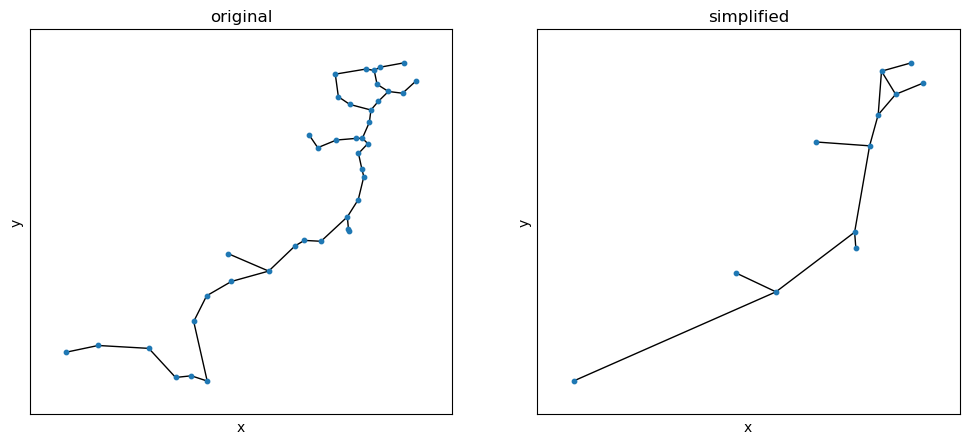

In [6]:
# Simple map view of original data (left) and simplified graph (right)
huttes.plot(with_labels=False, node_size=10)

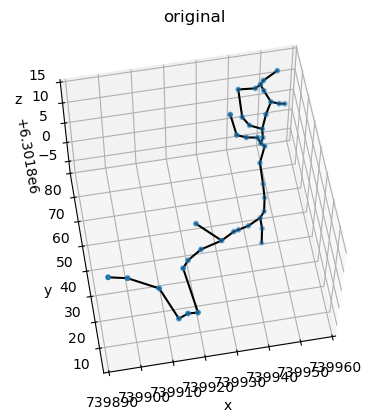

In [13]:
# Visualization of the original data
huttes.plot3d(zrotation=60, xyrotation=10, options_nodes={'s':10})

c:\Users\celia\anaconda3\envs\kntools\Lib\site-packages\karstnet\base.py:709: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
c:\Users\celia\anaconda3\envs\kntools\Lib\site-packages\karstnet\base.py:709: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  fig.tight_layout()


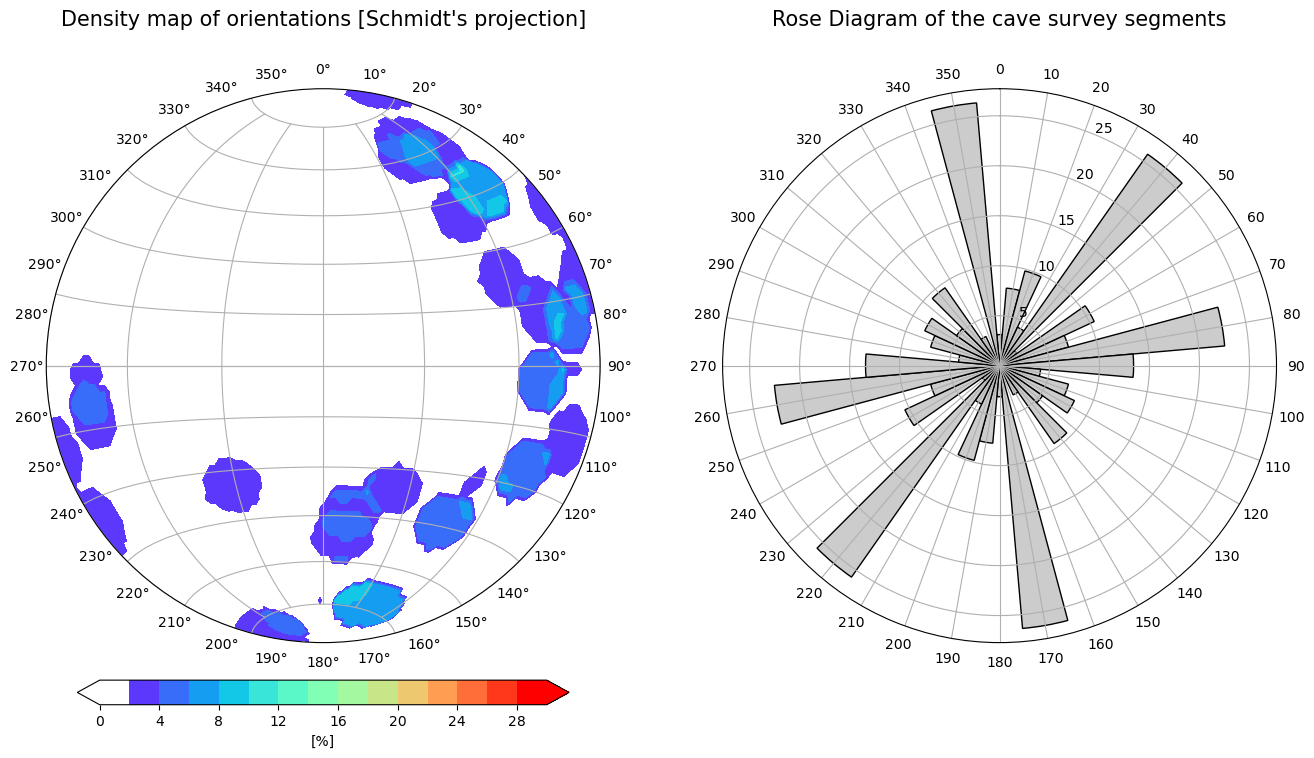

In [9]:
# Density map of orientation and rose diagram (use mplsstereonet library)
huttes.stereo()

(Upd. 26.08.2020) : To get Stereo and Rose diagram without weigthing by the lengths of the conduits, the option "weighted = False" can be used. As seen here, ignoring it can have a non negligeable impact...

c:\Users\celia\anaconda3\envs\kntools\Lib\site-packages\karstnet\base.py:709: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
c:\Users\celia\anaconda3\envs\kntools\Lib\site-packages\karstnet\base.py:709: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  fig.tight_layout()


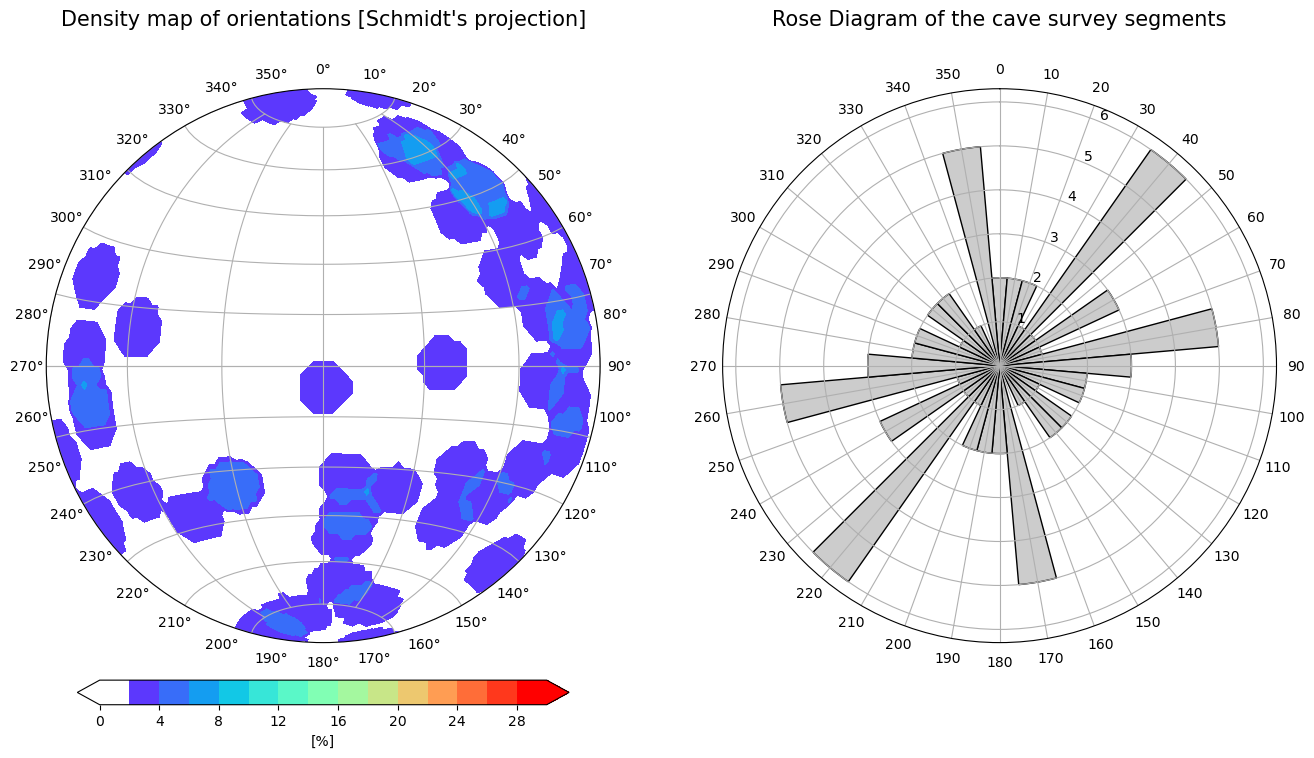

In [10]:
huttes.stereo(weighted = False)

### Computing the statistical metrics

The simplest way to obtain all the statistics for that graph is to call the characterize_graph function as follows.

In [11]:
results = huttes.characterize_graph( verbose=True )

Computing:
 - mean length, cv length, length entropy, mean tortuosity
 - orientation entropy, orientation 3d entropy
 - aspl, cpd, md, cv degree, cvd
--------------------------------------
 mean length               = 15.872
 cv length                 =  1.044
 length entropy            =  0.618
 tortuosity                =  1.207
 orientation entropy       =  0.926
 orientation 3d entropy    =  0.649
 aspl                      =  3.015
 cpd                       =  0.474
 mean degree               =  2.000
 cv degree                 =  0.522
 correlation vertex degree = -0.333
--------------------------------------


Compute basic graph analysis and Howard's parameters

In [12]:
huttes.basic_analysis()


This network (complete graph) contains :
     41 nodes (stations) and  41 edges.
 On the simplified graph, there are :
     12 nodes (stations) and  12 edges,
     6 are extremity nodes (entries or exits) and
     6 are junction nodes.
There is/are 1 connected component.s and 1 cycle.s.


Howard's parameter are (Howard, 1970) : 
   alpha : 0.05263157894736842 
   beta : 1.0 
   gamma : 0.4

Note that this computation considers the node of degree 2 necessary to loop preservations as Seed Nodes, in order to stay consistent with Howard's illustrations.
